### TF-IDF + ANN (from scratch)
I will use the Yelp Polarity dataset, which contains 560,000 reviews labeled as positive (1) or negative (0). We will preprocess the text data using TF-IDF vectorization and then train a simple Artificial Neural Network (ANN) for sentiment classification.

The ANN will use is one build for [Lab7](./../Lab7/ANN_noTool.py). So for more go see that file.

In [29]:
from datasets import load_dataset
import matplotlib.pyplot as plt

In [30]:
dataset = load_dataset("yelp_polarity")

train_texts  = dataset["train"]["text"][:50000]
train_labels = dataset["train"]["label"][:50000]
test_texts   = dataset["test"]["text"][:5000]
test_labels  = dataset["test"]["label"][:5000]

'[Errno 11002] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/yelp_polarity/resolve/bbf1c97a1f0cf005e5aded43839fd814654a1557/yelp_polarity.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since yelp_polarity couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at C:\Users\codri\.cache\huggingface\datasets\yelp_polarity\plain_text\0.0.0\bbf1c97a1f0cf005e5aded43839fd814654a1557 (last modified on Wed Apr 29 16:26:25 2026).


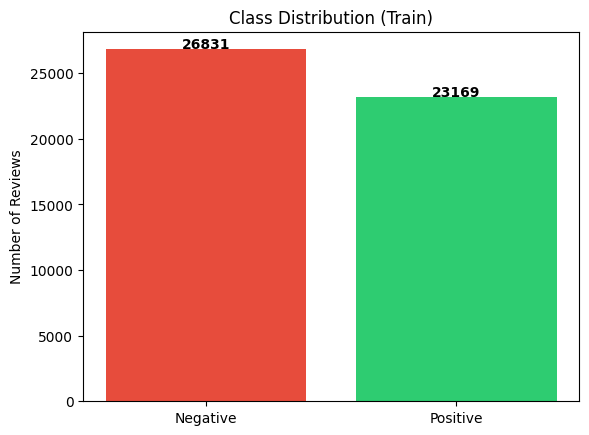

In [31]:
pos_count = train_labels.count(1)
neg_count = train_labels.count(0)

plt.bar(["Negative", "Positive"], [neg_count, pos_count], color=["#e74c3c", "#2ecc71"])
plt.title("Class Distribution (Train)")
plt.ylabel("Number of Reviews")
for i, v in enumerate([neg_count, pos_count]):
    plt.text(i, v + 100, str(v), ha="center", fontweight="bold")

(0.0, 1000.0)

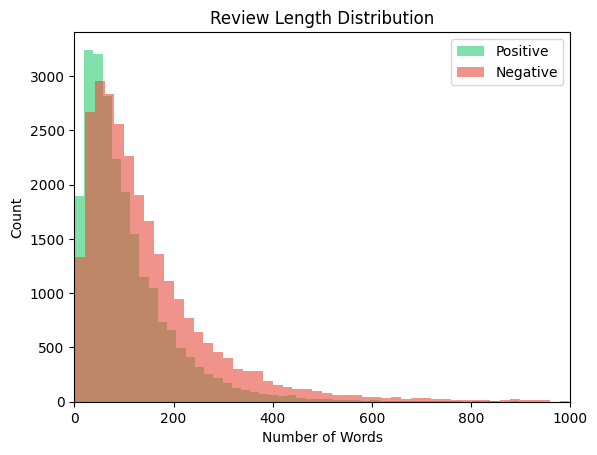

In [32]:
train_lengths = [len(text.split()) for text in train_texts]
pos_lengths   = [l for l, label in zip(train_lengths, train_labels) if label == 1]
neg_lengths   = [l for l, label in zip(train_lengths, train_labels) if label == 0]

plt.hist(pos_lengths, bins=50, alpha=0.6, color="#2ecc71", label="Positive")
plt.hist(neg_lengths, bins=50, alpha=0.6, color="#e74c3c", label="Negative")
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.legend()
plt.xlim(0, 1000)

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer(
	max_features=10000,    # keep only top 10000 words
	stop_words="english", # remove "the", "a", "is" etc.
	ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(train_texts)
X_test  = vectorizer.transform(test_texts)

y_train = np.array(train_labels)
y_test  = np.array(test_labels)

print(f"Vocabulary size  : {len(vectorizer.vocabulary_)}")
print(f"X_train shape    : {X_train.shape}")
print(f"X_test shape     : {X_test.shape}")

Vocabulary size  : 10000
X_train shape    : (50000, 10000)
X_test shape     : (5000, 10000)


In [38]:
from ANN_noTool import ANN_noTool # this is the ANN class from Lab7 copyed in this folder

ann = ANN_noTool()
ann.init_weights(
    input_size=10000,   # matches max_features in TfidfVectorizer
    hidden_size=128,
    output_size=1,
    learning_rate=0.01,
    alpha=0.0001,
    epochs=100
)

In [39]:
ann.train(X_train, y_train)

Training: 100%|██████████| 100/100 [11:03<00:00,  6.63s/epoch, cost=0.3090]


In [40]:
predictions = ann.predict(X_test)
accuracy = np.mean(predictions.flatten() == y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 88.76%


In [41]:
custom_text = "By choosing a bike over a car, I'm reducing my environmental footprint."
custom_vector = vectorizer.transform([custom_text]).toarray()
pred = ann.predict(custom_vector)
print(f"Sentiment: {'Positive' if pred[0] == 1 else 'Negative'}")

Sentiment: Positive
